In [33]:
%run "/home/nichettg/Codici/Laboratorio/moduli.py"

In [34]:
def nome (stringa):
    """
    Estrae il nome, cioè la frequenza, dal titolo di ogni file input letto
    """
    
    stringa_nuova = stringa.replace(f'./Data/{cartella}/tors_','').replace('.csv','').replace('h','H')
    return stringa_nuova

# 1. Raccolta Dati

In [35]:
giorno = 1

cartella = f"Giorno{giorno}"

In [36]:
input_files = [f"./Data/{cartella}/{nome_file}" for nome_file in sorted(os.listdir(f'./Data/Giorno{giorno}'))]
dati= {}

for i, input_file in enumerate(input_files):
    letti = pd.read_csv(input_file)

    dati[nome(input_file)] = {
        "tempo": letti["Tempo"],
        "forzante": letti["Forzante"],
        "pendolo" : letti["Pendolo"],
        "ampiezza" : letti["Ampiezza"],
        "fase" : letti["Fase"],
    }

if giorno == 1:
    dati1 = dati.copy()
elif giorno == 2:
    dati2 = dati.copy()

In [37]:
#gf.display_dizionario(dati)

# 2. Analisi Oscillazione Forzata

## 2.1 Grafici Confronto Oscillazione

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


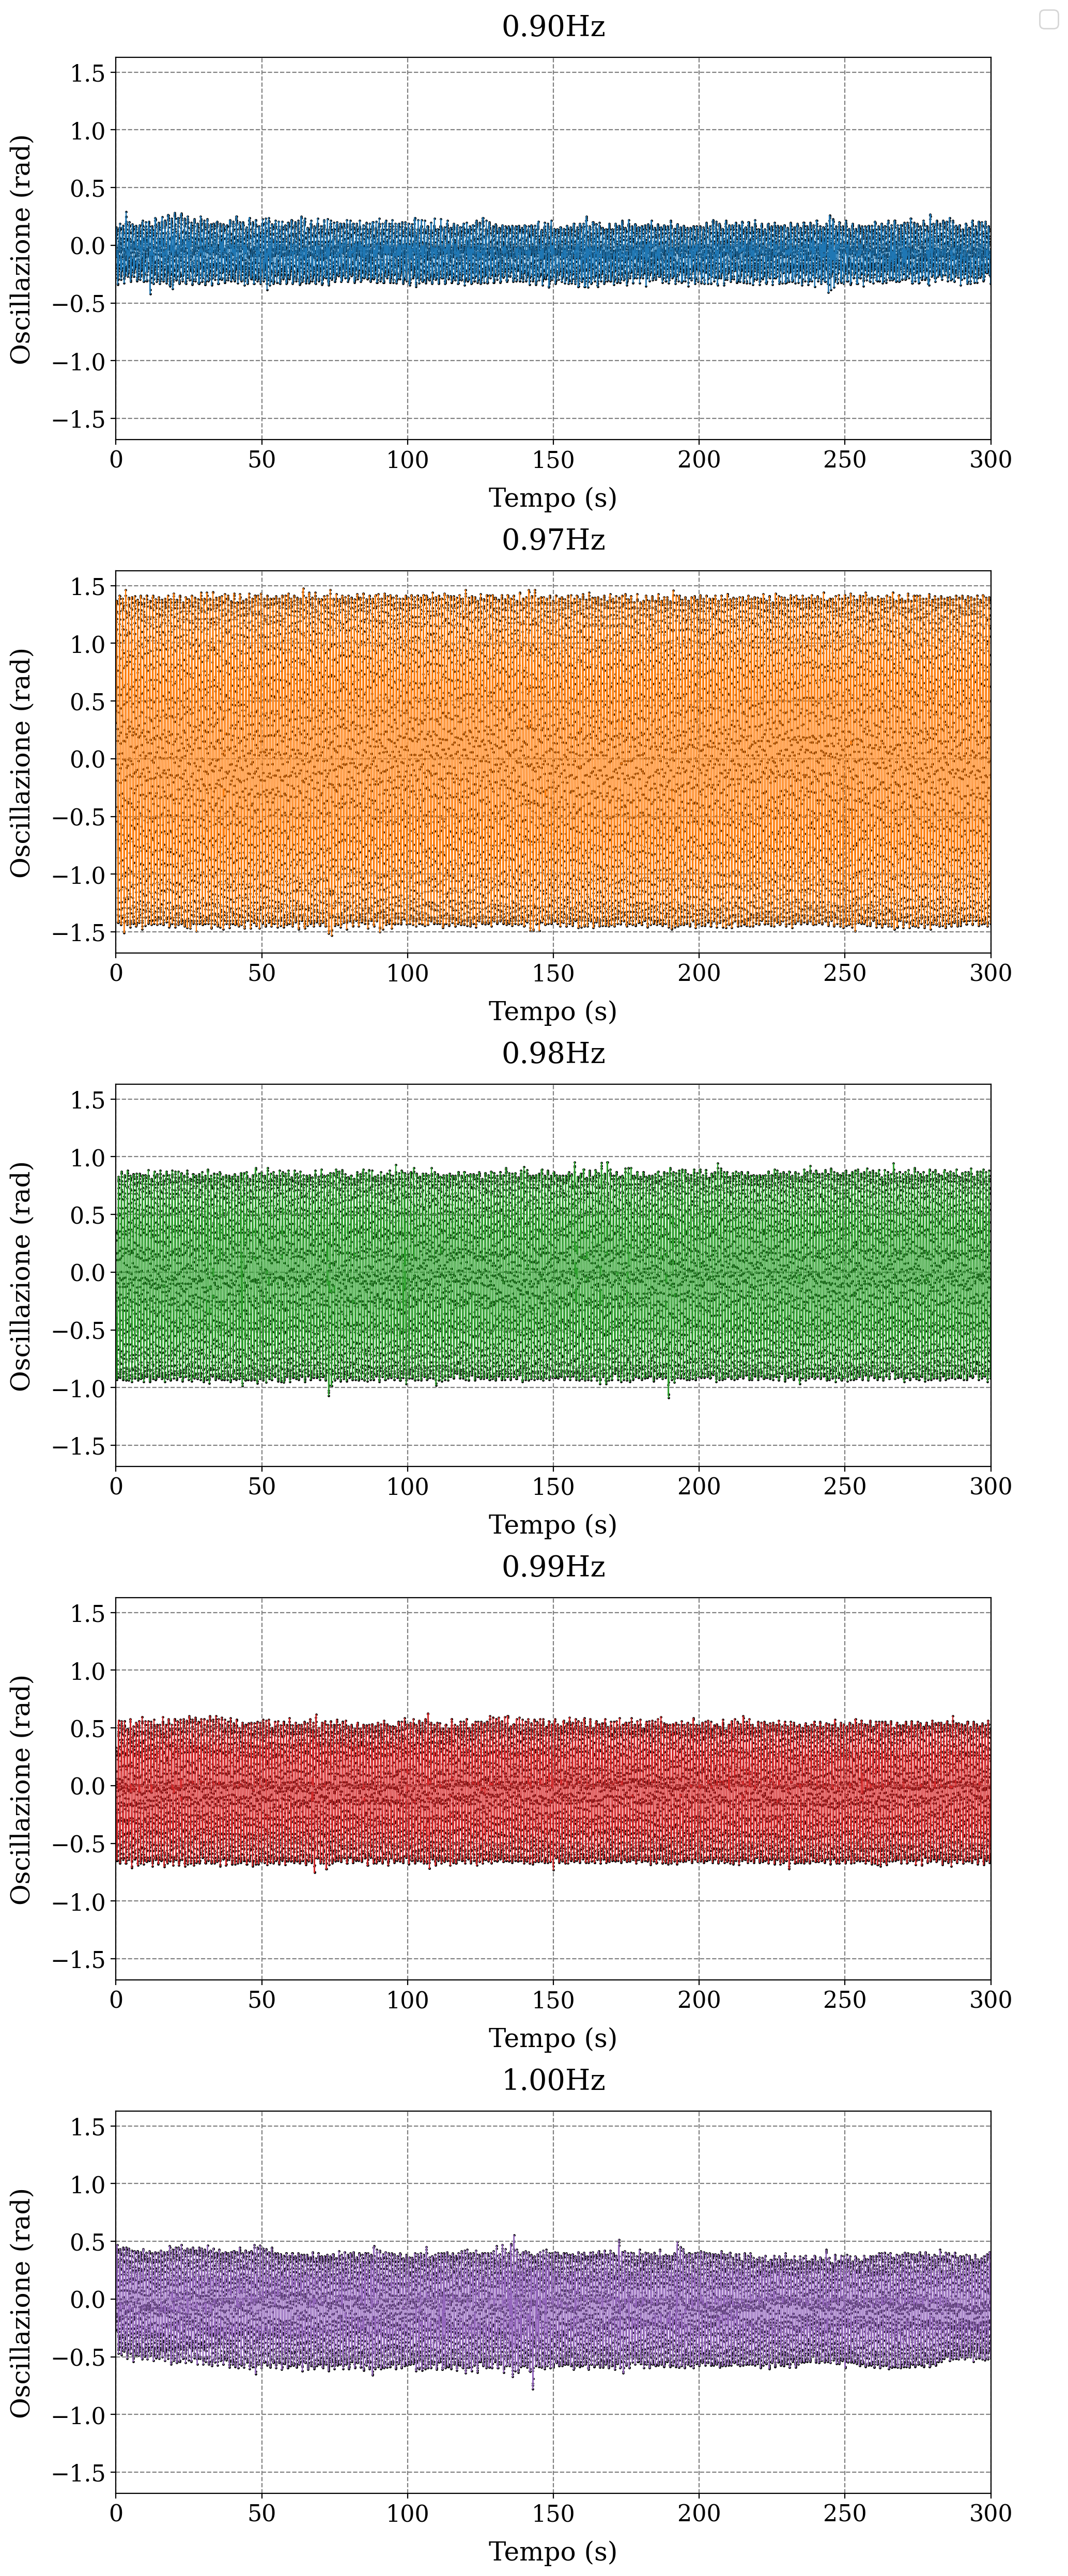

In [38]:
fig,axes = plt.subplots(len(input_files), 1, figsize=(10, len(input_files)*5), sharey=True)

for i, input_file in enumerate(input_files):

    ax = axes[i]

    titolo = nome(input_file)
    colore = next(color_cycle)

    x = dati[titolo]["tempo"]
    y = dati[titolo]["pendolo"] * (2*np.pi)

    ax.plot(x, y, color=colore, linewidth=0.7)
    ax.scatter(x, y, color="black", s=0.5)

    gf.parametri_grafico(ax, titolo, "Tempo (s)", "Oscillazione (rad)")
    ax.set_xlim(0,300)
gf.salva_grafico(fig, f"./Images/{cartella}/ConfrontoForzanti.pdf")

## 2.2 Calcolo Ampiezze Oscillazione

Vengono trovati massimi e minimi delle oscillazioni, viene poi fatta la media dei minimi e dei massimi singolarmente per poi fare la media tra i due. Vengono supposti gaussiani il campione dei massimi e quello dei minimi, considerando poi come ampiezza di oscillazione la media tra i due.

In [39]:
for i, serie in enumerate(dati.keys()):
    valori = dati[serie]["pendolo"] * (2*np.pi)
    tempi = dati[serie]["tempo"]
    massimi, massimi_t = [], []
    minimi, minimi_t = [], []

    periodo = 1 / float(str(serie).replace("Hz",""))
    raggio = int((periodo / 2) * 50)

    fine_forzante = np.argmin(np.convolve(np.abs(dati[titolo]["forzante"]), np.ones(4), mode='valid'))

    for j, val in enumerate(valori):
        if j > fine_forzante:
            break
        if j < raggio or j > len(valori) - raggio - 1:
            continue
        # Massimi
        if all(val > valori[j + k] for k in range(-raggio, raggio + 1) if k != 0):
            massimi.append(val)
            massimi_t.append(tempi[j])
        # Minimi
        if all(val < valori[j + k] for k in range(-raggio, raggio + 1) if k != 0):
            minimi.append(val)
            minimi_t.append(tempi[j])

    print(f"Serie {serie}: {len(massimi)} massimi e {len(minimi)} minimi trovati \n Periodo = {periodo:.2f} s \n Intorno = {2 * raggio}")

Serie 0.90Hz: 209 massimi e 233 minimi trovati 
 Periodo = 1.11 s 
 Intorno = 54
Serie 0.97Hz: 259 massimi e 247 minimi trovati 
 Periodo = 1.03 s 
 Intorno = 50
Serie 0.98Hz: 243 massimi e 244 minimi trovati 
 Periodo = 1.02 s 
 Intorno = 50
Serie 0.99Hz: 242 massimi e 225 minimi trovati 
 Periodo = 1.01 s 
 Intorno = 50
Serie 1.00Hz: 252 massimi e 242 minimi trovati 
 Periodo = 1.00 s 
 Intorno = 50


Viene applicata la correzione per centrare le oscillazioni in zero.

In [40]:
offset = {}
for chiave,serie in dati.items():
    fine_forzante = np.argmin(abs(dati[chiave]["forzante"]))
    offset[chiave] = np.mean(serie["pendolo"][fine_forzante:] * (2*np.pi))

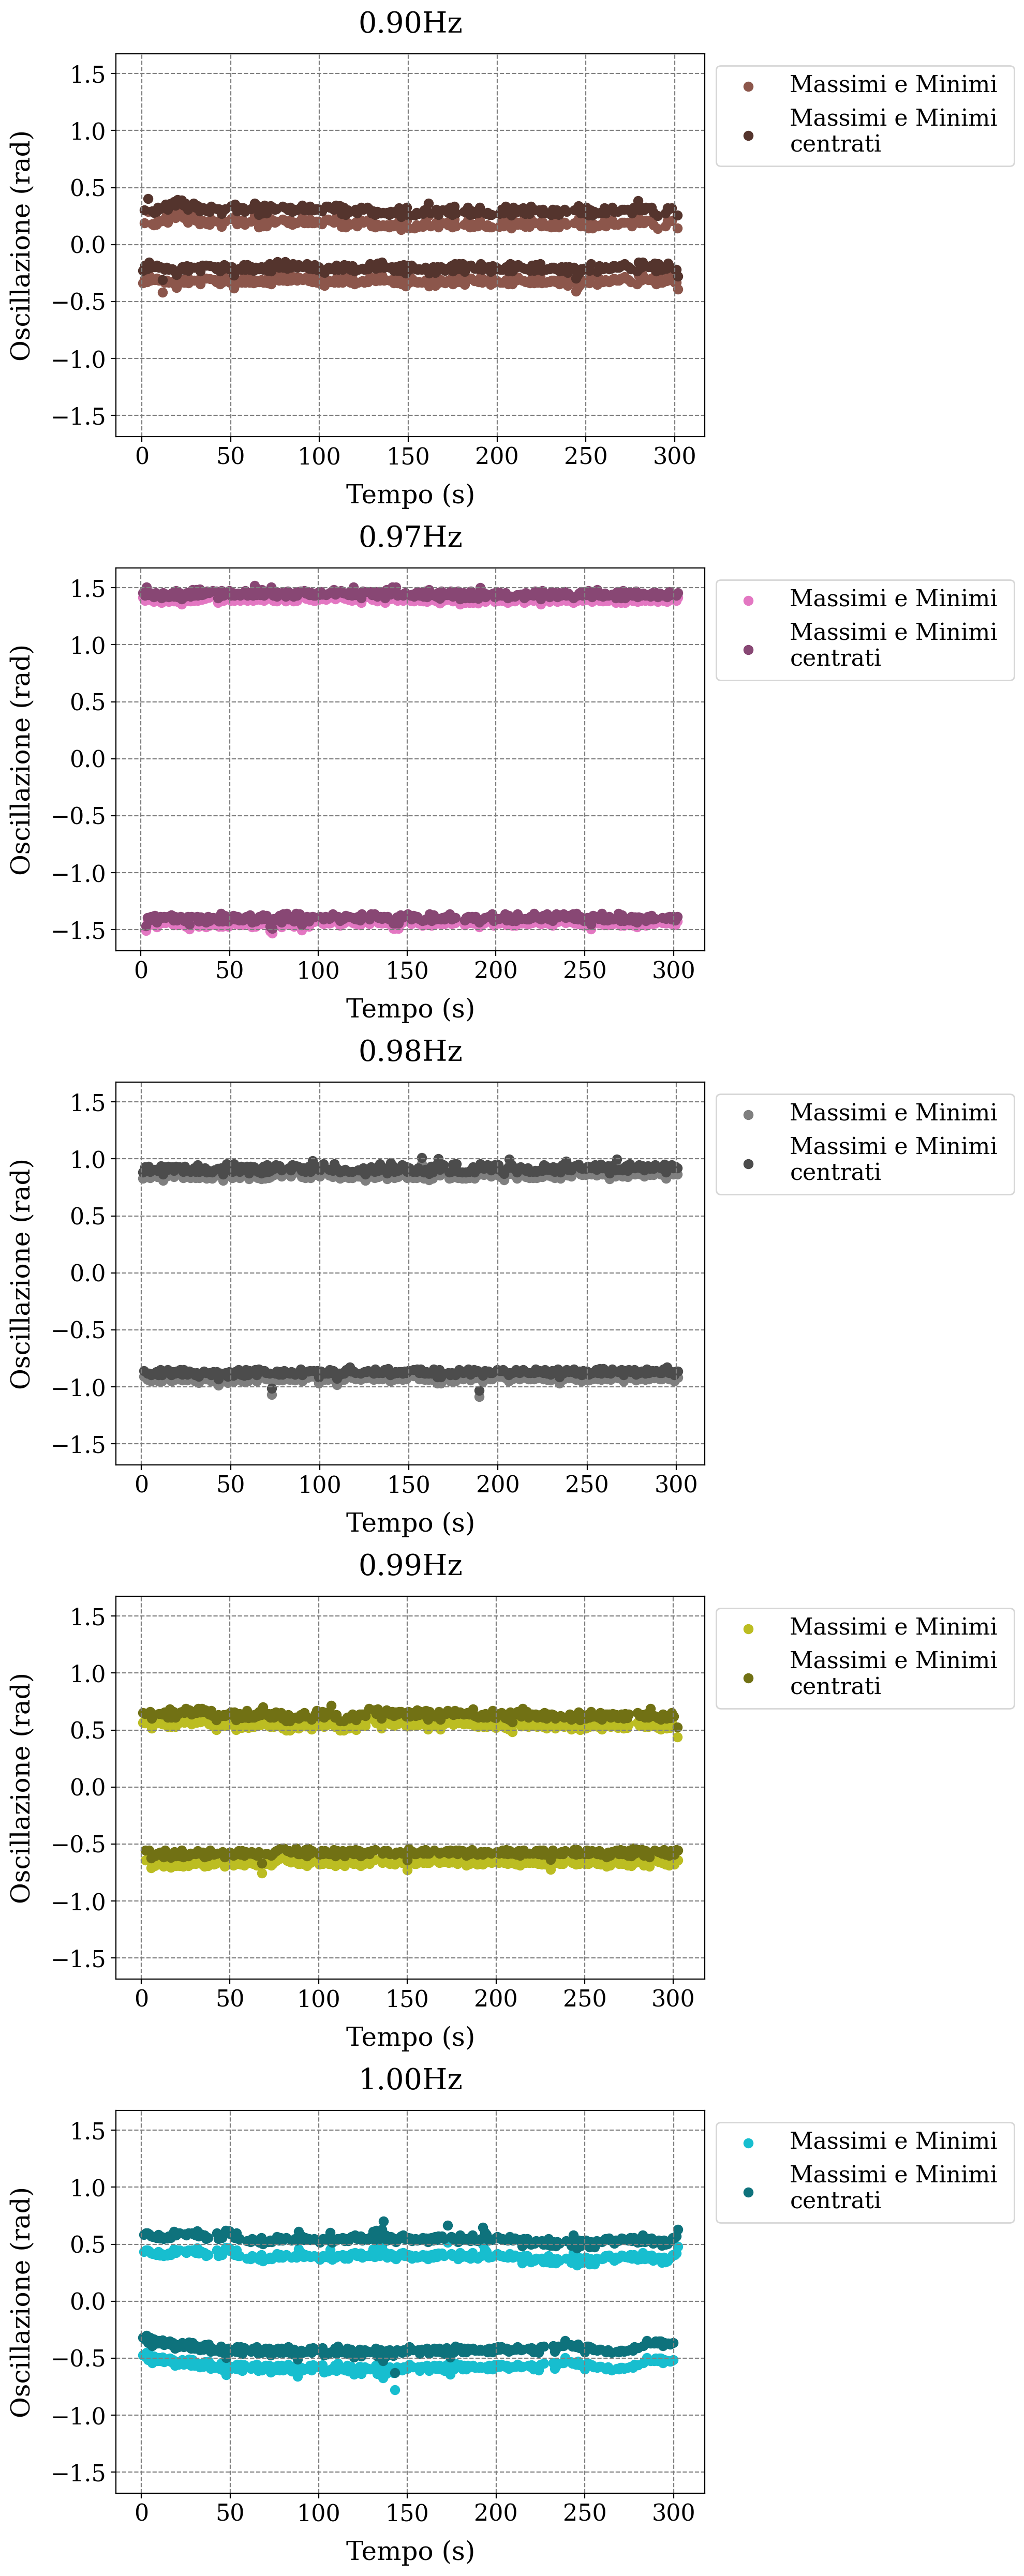

In [41]:
ampiezze,ampiezze_noncorrette,sampiezze = {},{},{}
fig,axes = plt.subplots(len(input_files), 1, figsize=(10, len(input_files)*5), sharey=True)

for i, serie in enumerate(dati.keys()):
    valori = dati[serie]["pendolo"] * (2*np.pi)
    tempi = dati[serie]["tempo"]
    massimi, massimi_t = [], []
    minimi, minimi_t = [], []

    periodo = 1 / float(str(serie).replace("Hz",""))
    raggio = int((periodo / 2) * 50)

    fine_forzante = np.argmin(abs(dati[titolo]["forzante"]))

    for j, val in enumerate(valori):
        if j > fine_forzante:
            break
        if j < raggio or j > len(valori) - raggio - 1:
            continue
        # Massimi
        if all(val > valori[j + k] for k in range(-raggio, raggio + 1) if k != 0):
            massimi.append(val)
            massimi_t.append(tempi[j])
        # Minimi
        if all(val < valori[j + k] for k in range(-raggio, raggio + 1) if k != 0):
            minimi.append(val)
            minimi_t.append(tempi[j])

    label1 = f"Massimi e Minimi"
    label2 = f"Massimi e Minimi \ncentrati"

    ax = axes[i]
    colore = next(color_cycle)
    ax.scatter(massimi_t, massimi, color=colore)
    ax.scatter(minimi_t, minimi, color=colore, label=label1)

    ax.scatter(massimi_t, massimi - offset[serie], color=gf.darken(colore))
    ax.scatter(minimi_t, minimi - offset[serie], color=gf.darken(colore), label=label2)
    ax.legend(bbox_to_anchor=(1,1), loc='upper left')

    #gf.linea(ax, minimi_t, salto=np.mean(massimi - offset[serie]), color="blue")
    #gf.linea(ax, massimi_t, salto=np.mean(np.abs(minimi - offset[serie])), color="red")

    gf.parametri_grafico(ax, f"{serie}", "Tempo (s)", "Oscillazione (rad)")

    # Calcolo dell'ampiezza
    dati_centrati = np.abs(np.concatenate([massimi - offset[serie], -(minimi - offset[serie])]))
    ampiezze[serie] = np.mean(dati_centrati)
    sampiezze[serie] = np.std(dati_centrati, ddof=1) / np.sqrt(len(dati_centrati))
    ampiezze_noncorrette[serie] = (abs(np.mean(massimi)) + abs(np.mean(minimi))) / 2

gf.salva_grafico(fig, f"./Images/{cartella}/ConfrontoMassimi.pdf", noLegenda=True)

In [42]:
gf.display_dizionario(ampiezze)
gf.display_dizionario(ampiezze_noncorrette)

if giorno == 1:
    ampiezze1 = ampiezze.copy()
    sampiezze1 = sampiezze.copy()
elif giorno == 2:
    ampiezze2 = ampiezze.copy()
    sampiezze2 = sampiezze.copy()

0.90Hz,0.2523330410873826
0.97Hz,1.4225075421562967
0.98Hz,0.8944636160218935
0.99Hz,0.6070472459284757
1.00Hz,0.4851351146054323


0.90Hz,0.25499562507817913
0.97Hz,1.4219566899906009
0.98Hz,0.8945074692724654
0.99Hz,0.6060107996104105
1.00Hz,0.4838253595149379


## 2.3 Fit Lorentziano

---

$$
L(x) = \frac{A}{(B + x^2)^2 + C x^2}
$$

dove:

- ( $A$ ): costante di scala, legata all'altezza del picco  
- ( $B = \omega_0^2$ ): frequenza di risonanza, corrisponde alla posizione del picco  
- ( $C = \gamma^2$ ): larghezza a metà altezza (HWHM), legata allo smorzamento del sistema

$$
L(x) = \frac{A}{(\omega_0^2 + x^2)^2 + \gamma^2 x^2}
$$

---

Fit lorentziano:

A: $(325.5 \pm 1.9) \times 10^{-4}$

B: $(9645.8 \pm 1.5) \times 10^{-4}$

C: $(1054.8 \pm 3.3) \times 10^{-5}$

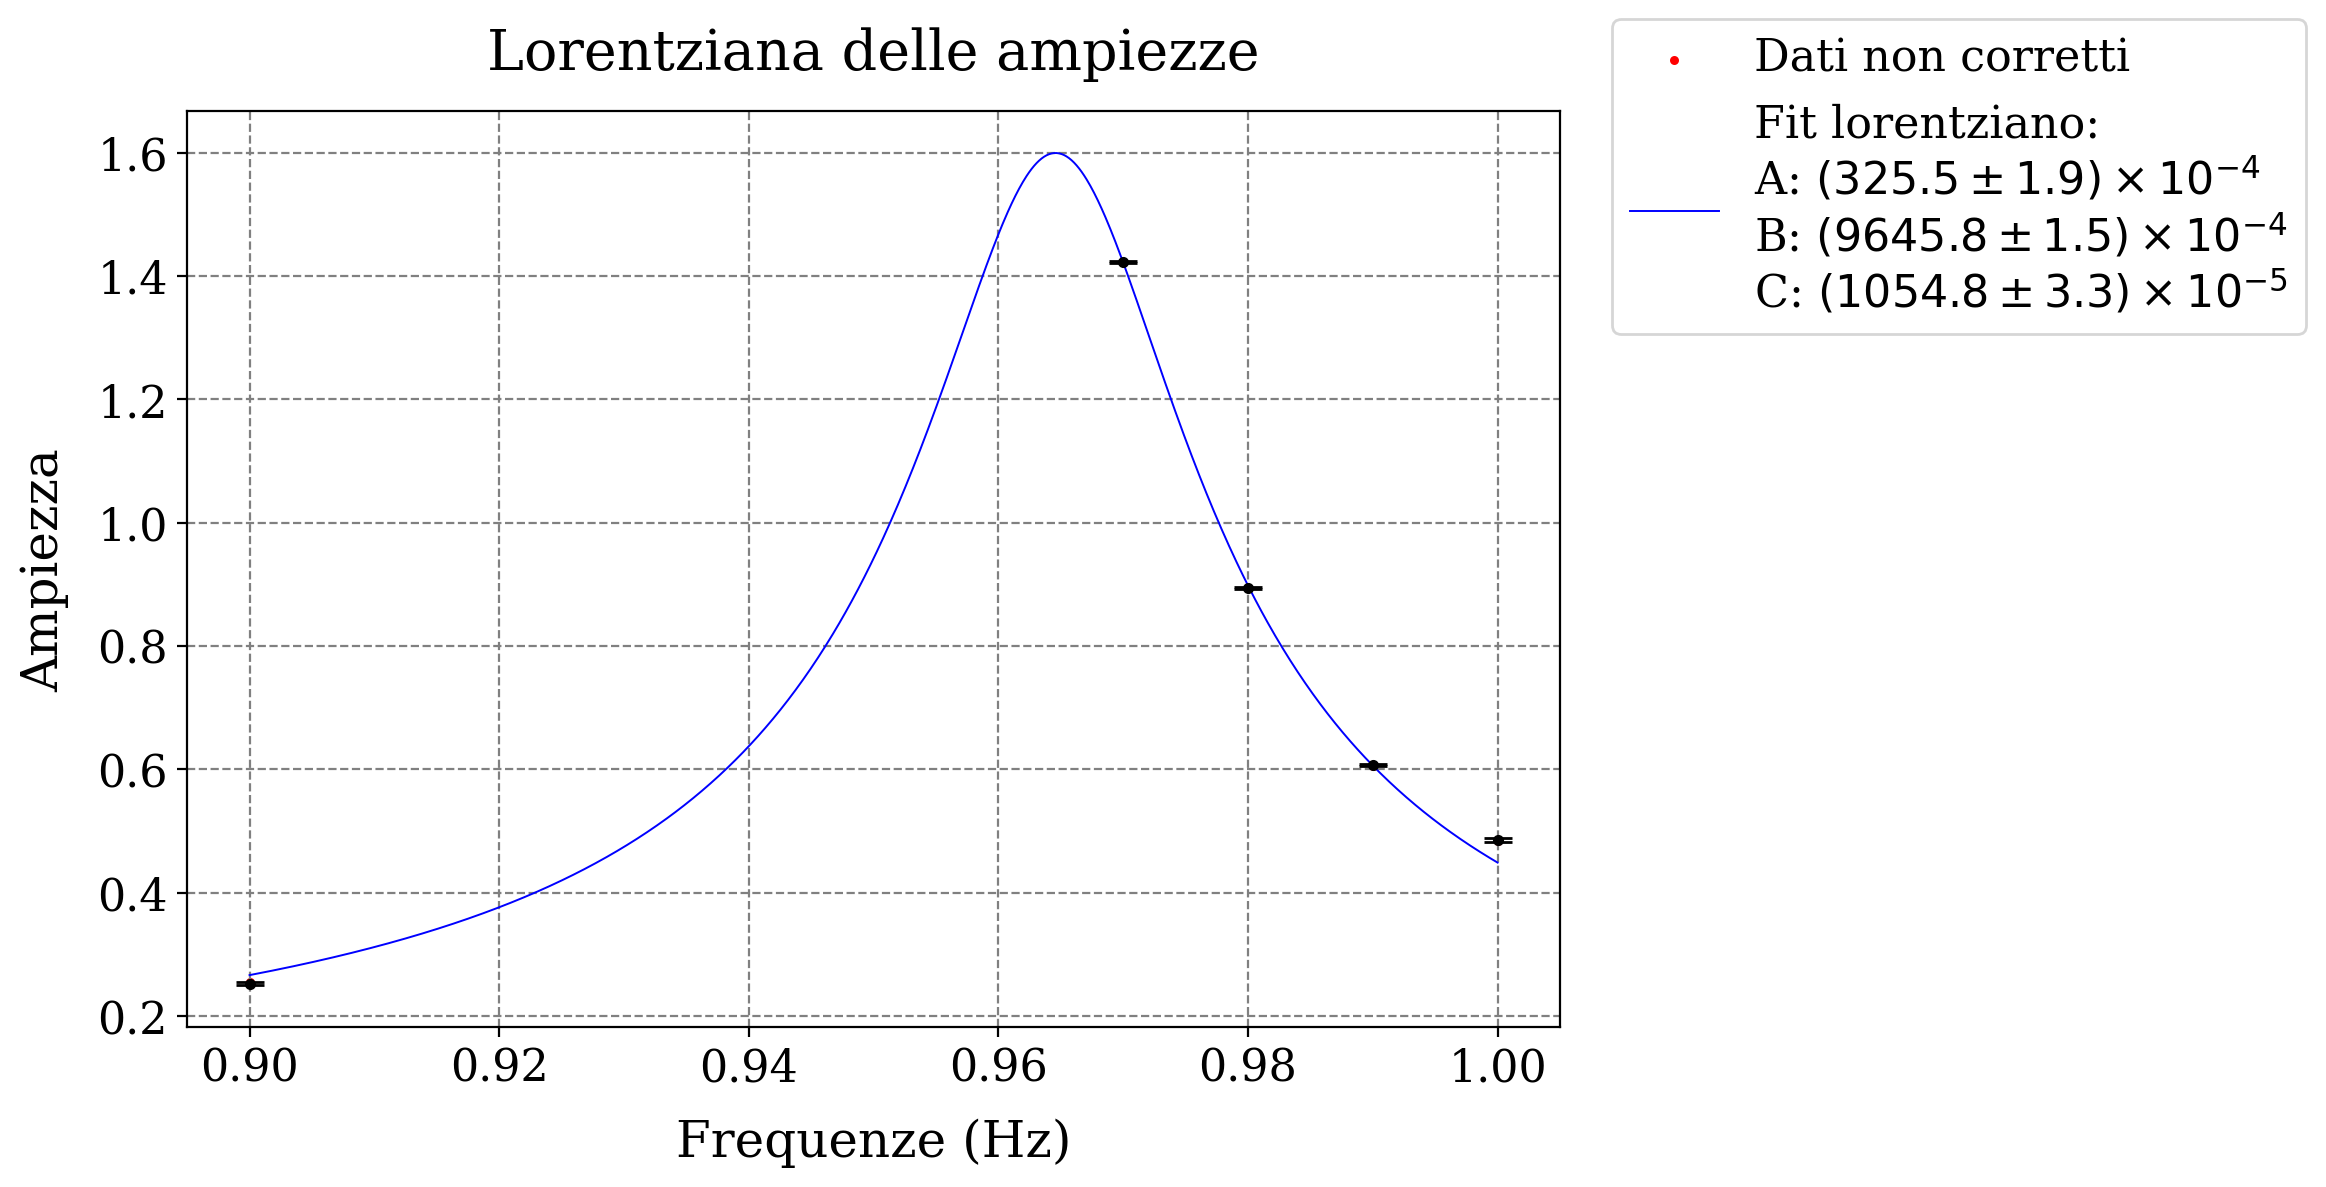

In [44]:
from scipy.optimize import curve_fit
from IPython.display import display, Markdown
default = gf.default_error_params()

def lorentziana(x, A, B, C):
    num = A
    den = np.sqrt((B**2 + 2*C**2 - x**2)**2 + 4*C**2 * x**2)
    return num / den


frequenze = [float(key.replace('Hz', '')) for key in dati.keys()]
ampiezze_valori = list(ampiezze.values())
ampiezze_err = list(sampiezze.values())

fig, ax = plt.subplots()
ax.scatter(frequenze, ampiezze_noncorrette.values(), color='red', label='Dati non corretti', s=5)
ax.errorbar(frequenze, ampiezze_valori, yerr=ampiezze_err, color='black', fmt='o', markersize=3, **default)

A0 = max(ampiezze_valori)
B0 = frequenze[np.argmax(ampiezze_valori)]
C0 = (max(frequenze) - min(frequenze)) / 10

p0 = [A0, B0, C0]
popt, pcov = curve_fit(
    lorentziana,
    frequenze,
    ampiezze_valori,
    sigma=ampiezze_err,
    p0=p0,
    absolute_sigma=True
)
perr = np.sqrt(np.diag(pcov))

label = [
    "Fit lorentziano:",
    rf"A: {gf.formatta_errore(popt[0], perr[0])}",
    rf"B: {gf.formatta_errore(popt[1], perr[1])}",
    rf"C: {gf.formatta_errore(popt[2], perr[2])}",
]

x_fit = np.linspace(min(frequenze), max(frequenze), 1000)
y_fit = lorentziana(x_fit, *popt)
ax.plot(x_fit, y_fit, color='blue', linewidth=0.7, label='\n'.join(label))
#ax.plot(x_fit, y_fit, color='blue', linewidth=0.7)

display(Markdown('\n\n'.join(label)))

gf.parametri_grafico(ax, "Lorentziana delle ampiezze", "Frequenze (Hz)", "Ampiezza")
gf.salva_grafico(fig, f"./Images/{cartella}/Lorentziana.pdf")

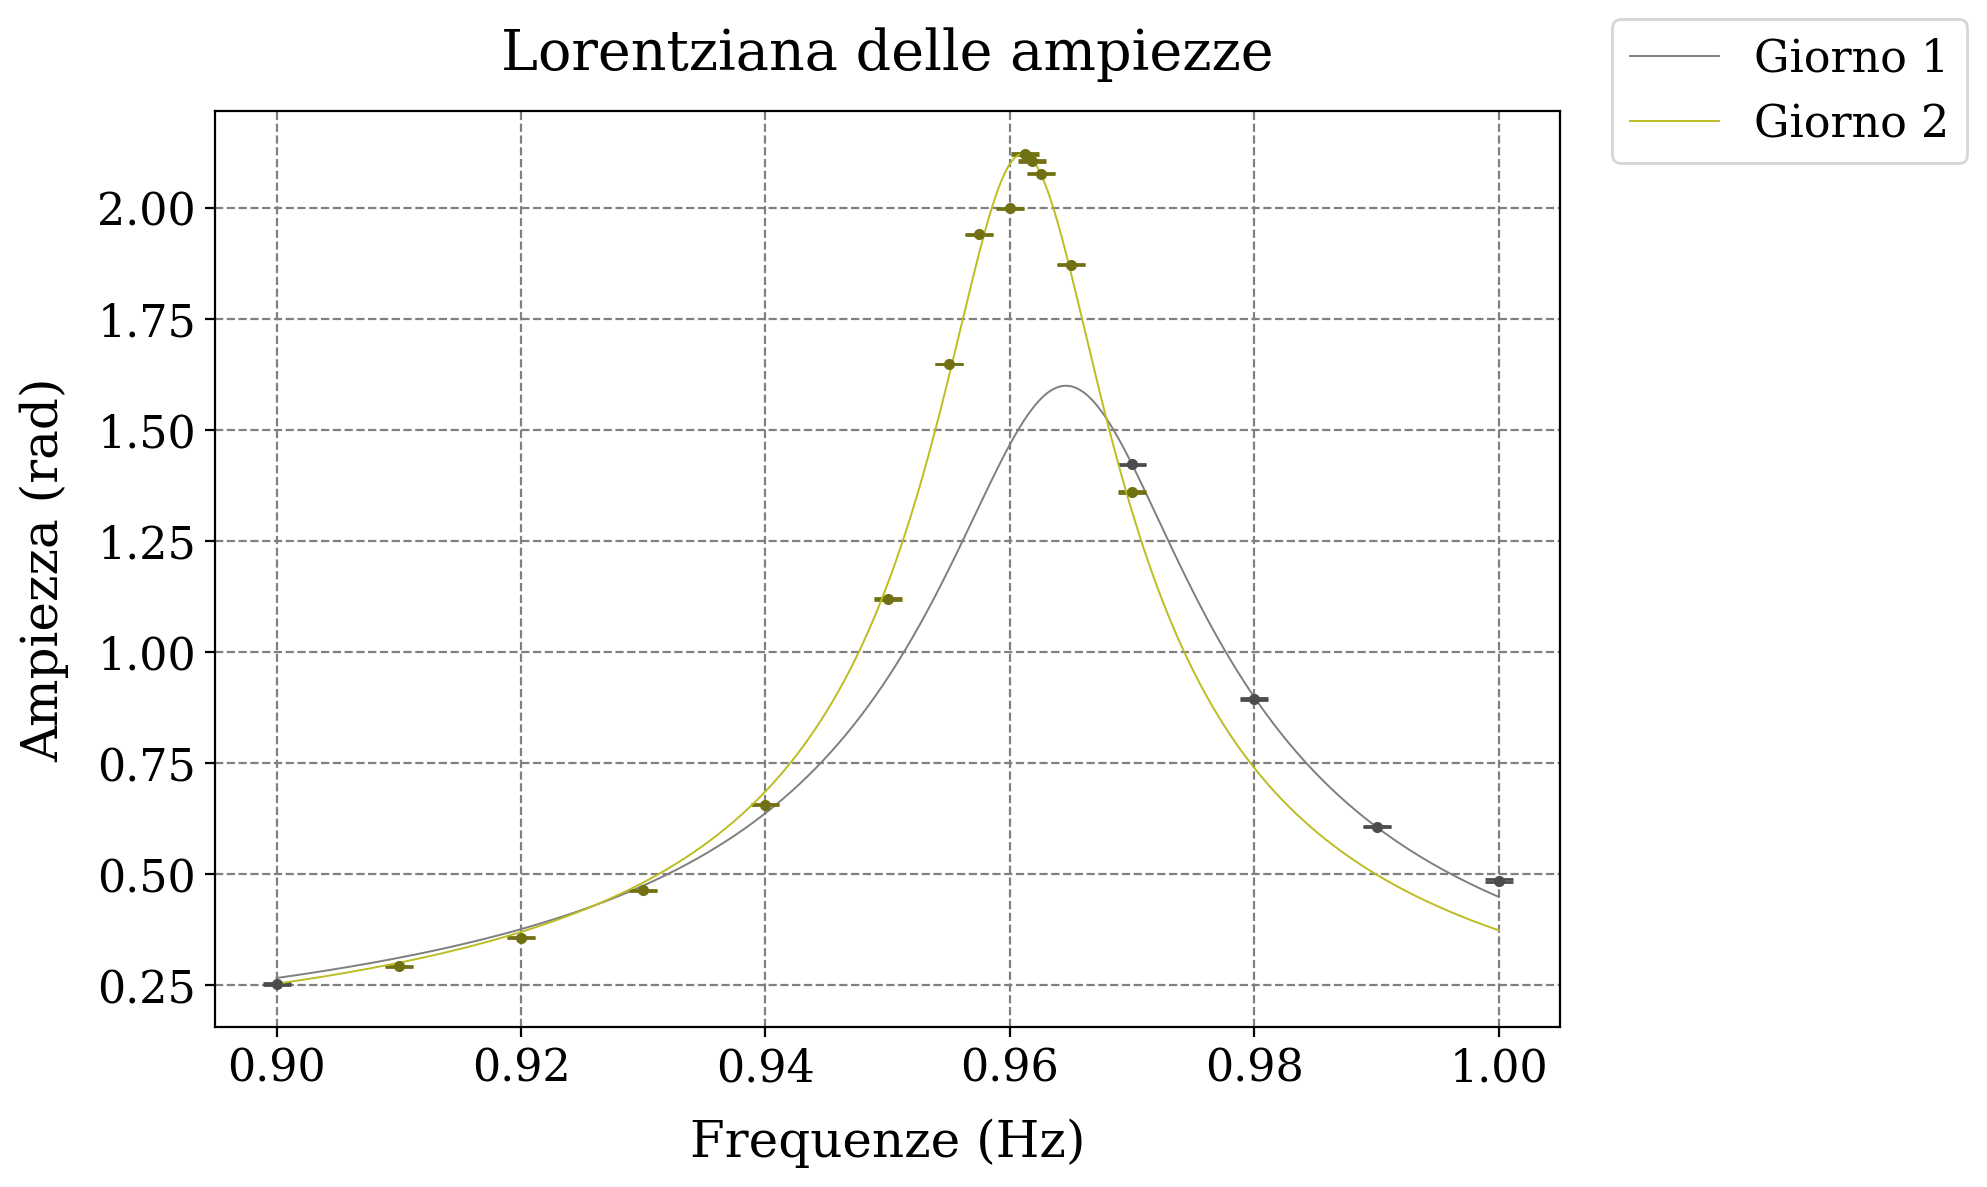

In [66]:
fig, ax = plt.subplots()

for i, (data, ampiezze, sampiezze) in enumerate(zip([dati1, dati2], [ampiezze1, ampiezze2], [sampiezze1, sampiezze2])):
    frequenze = [float(key.replace('Hz', '')) for key in data.keys()]
    ampiezze_valori = list(ampiezze.values())
    ampiezze_err = list(sampiezze.values())

    label = f"Giorno {i + 1}"

    color = next(color_cycle)

    ax.errorbar(frequenze, ampiezze_valori, yerr=ampiezze_err, color=gf.darken(color), fmt='o', markersize=3, **default)

    A0 = max(ampiezze_valori)
    B0 = frequenze[np.argmax(ampiezze_valori)]
    C0 = (max(frequenze) - min(frequenze)) / 10

    p0 = [A0, B0, C0]
    popt, pcov = curve_fit(
        lorentziana,
        frequenze,
        ampiezze_valori,
        sigma=ampiezze_err,
        p0=p0
    )

    x_fit = np.linspace(0.9, 1, 1000)
    y_fit = lorentziana(x_fit, *popt)
    ax.plot(x_fit, y_fit, color=color, linewidth=0.7, label=label)

gf.parametri_grafico(ax, "Lorentziana delle ampiezze", "Frequenze (Hz)", "Ampiezza (rad)")
gf.salva_grafico(fig, f"./Images/Lorentziana.pdf")

# 3. Analisi Oscillazione Smorzata

## 3.1 Grafici Confronto Oscillazione

Tempo in cui vengono tagliati i dati.

In [ ]:
fine = 400

I dati sono stati corretti avendo considerato l'offset.

In [ ]:
gf.display_dizionario(offset) # in rad

In [ ]:
dati_tagliati = {}
fig, axes = plt.subplots(len(input_files), 1, figsize=(10, len(input_files)*5 ), sharey=True)

for i, input_file in enumerate(input_files):
    ax = axes[i]
    
    titolo = nome(input_file)
    colore = next(color_cycle_fisso)

    x = dati[titolo]["tempo"]
    y = dati[titolo]["pendolo"] * (2 * np.pi) - offset[titolo] # in rad e centrato

    # Calcolo indice di fine oscillazione forzante (inizio smorzamento)
    fine_forzante = np.argmin(np.convolve(np.abs(dati[titolo]["forzante"]), np.ones(4), mode='valid'))
    fine_taglio = np.searchsorted(x, fine)
    
    # Taglio i dati SOLO per la serie corrente
    dati_tagliati[titolo] = {
        "tempo": x[fine_forzante:fine_taglio].reset_index(drop=True),
        "pendolo": y[fine_forzante:fine_taglio].reset_index(drop=True),
    }

    x_tagliati = dati_tagliati[titolo]["tempo"]
    y_tagliati = dati_tagliati[titolo]["pendolo"]

    ax.plot(x_tagliati, y_tagliati, color=colore, linewidth=0.7)
    ax.scatter(x_tagliati, y_tagliati, color="black", s=0.5)

    gf.parametri_grafico(ax, titolo, "Tempo (s)", "Oscillazione (rad)")

gf.salva_grafico(fig, f"./Images/{cartella}/ConfrontoSmorzati.pdf")

In [ ]:
gf.display_dizionario(dati_tagliati)

## 3.2 Calcolo Ampiezze Oscillazione e Fit Esponenziale

L'oscillazione durante la fase di smorzamento viene lineareizzata graficando il logaritmo naturale sulle ordinate. Il fit viene eseguito a partire dal momento in cui viene azzerata l'oscillazione forzante e fino ai 2/5 (arbitrario) dell'x range. La numerosità del campione è sufficientemente elevata da potersi permettere di tagliare con così tanta superficialità i dati avanti nel tempo, i quali sono più soggetti a rumore di fondo.

In [ ]:
grafico_controllo_2 = True

In [ ]:
tagliati = {}
gamma = {}

if grafico_controllo_2: fig,axes = plt.subplots(len(input_files), 1, figsize=(10, len(input_files)*5 ), sharey=True)

for i, serie in enumerate(dati_tagliati.keys()):
    valori = dati_tagliati[serie]["pendolo"] * (2*np.pi)
    tempi = dati_tagliati[serie]["tempo"]
    massimi, massimi_t = [], []
    minimi, minimi_t = [], []

    periodo = 1 / float(str(serie).replace("Hz",""))
    raggio = max(1, int((periodo / 2) * 50))  # almeno 1

    for j, val in enumerate(valori):
        if j < raggio or j > len(valori) - raggio - 1:
            continue
        # Massimi
        if all(val > valori[j + k] for k in range(-raggio, raggio + 1) if k != 0):
            massimi.append(abs(val))
            massimi_t.append(tempi[j])
        # Minimi
        if all(val < valori[j + k] for k in range(-raggio, raggio + 1) if k != 0):
            minimi.append(abs(val))
            minimi_t.append(tempi[j])

    tagliati[serie] = {
        "tempo_minimi" : pd.Series(minimi_t),
        "minimi" : pd.Series(minimi),
        "tempo_massimi" : pd.Series(massimi_t),
        "massimi" : pd.Series(massimi),
    }

    #print(f"Serie {serie}: {len(massimi)} massimi e {len(minimi)} minimi trovati \n Periodo = {periodo:.2f} s \n Intorno = {2 * raggio}")

    err_pendolo = (0.001 * 2 * np.pi) / np.sqrt(12)
    
    # Grafico
    ax = axes[i]
    colore = next(color_cycle)
    
    # Fit
    index = int(len(massimi_t) / 5 * 2)
    x = np.concatenate([massimi_t[:index], minimi_t[:index]])
    y = np.concatenate([np.log(massimi[:index]), np.log(minimi[:index])])
    p = f.elaborato(x,y,err_pendolo, "skip", 0, elaborato=False, ritorno=True)
    a = p[0]
    b = p[1]
    sa = p[2]
    sb = p[3]
    p_value = p[5]
    label = [
        rf"a = {gf.formatta_errore(a, sa)}",
        f" b = {gf.formatta_errore(b, sb)}",
        #f"p-value: {p_value:.2e}"
    ]
    x_fit = np.linspace(min(x), max(x), 1000)
    y_fit = a + b * x_fit
    ax.plot(x_fit, y_fit, color=colore, linewidth=0.7, label='\n'.join(label))
    ax.legend(bbox_to_anchor=(1,1), loc='upper left')
    ax.errorbar(massimi_t, np.log(massimi), yerr=err_pendolo, color=colore, fmt='.', **default)
    ax.errorbar(minimi_t, np.log(minimi), yerr=err_pendolo, color=gf.darken(colore), fmt='.', **default)
    gf.parametri_grafico(ax, f"{serie}", "Tempo (s)", "ln(Oscillazione (rad))")

    gamma[serie] = {
        "b" : b,
        "sb" : sb,
    }
gf.salva_grafico(fig, f"./Images/{cartella}/ConfrontoMassimiSmorzamento.pdf",noLegenda=True)

if giorno == 1:
    gamma1 = gamma.copy()
elif giorno == 2:
    gamma2 = gamma.copy()

In [ ]:
#gf.display_dizionario(tagliati)

In [ ]:
#gf.display_dizionario(gamma)

Miglior stima di gamma

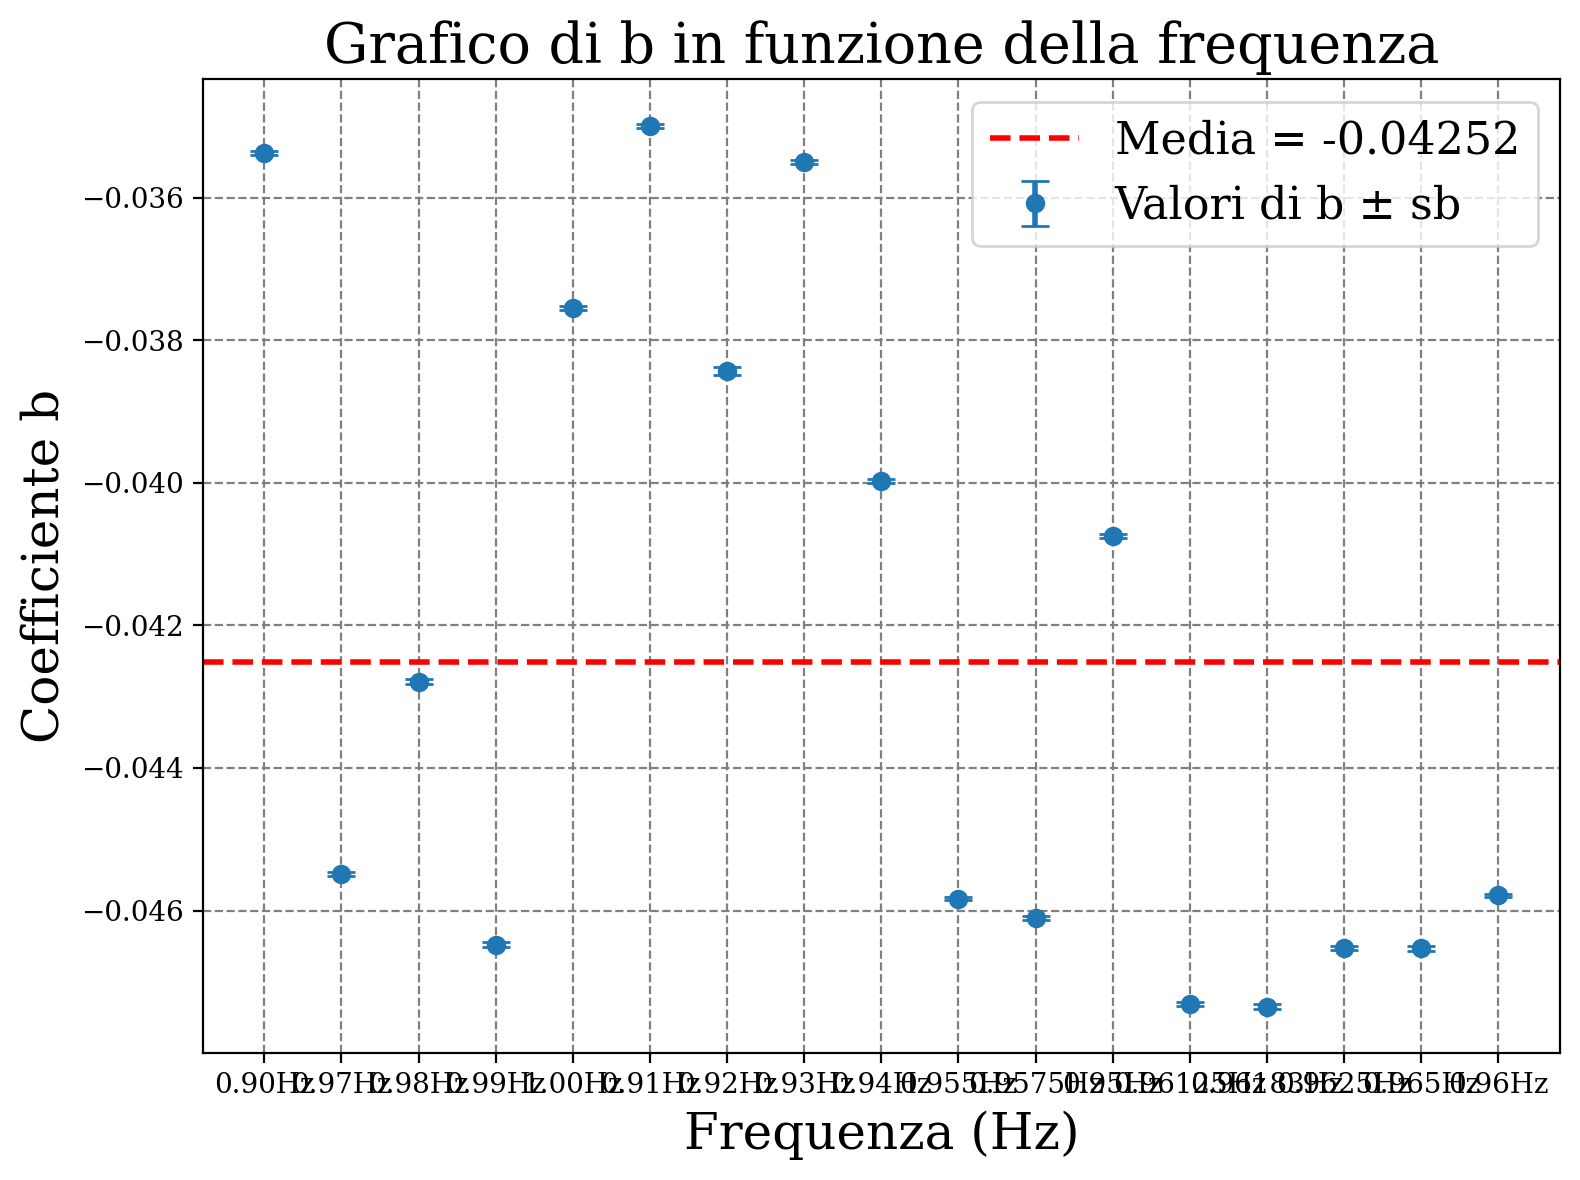

In [47]:
gamma_tot = {**gamma1, **gamma2}
# Estrazione dei dati
frequenze = list(gamma_tot.keys())
b_values = [gamma_tot[f]['b'] for f in frequenze]
sb_values = [gamma_tot[f]['sb'] for f in frequenze]

# Calcolo della media
b_mean = np.mean(b_values)

# Creazione del grafico
plt.errorbar(frequenze, b_values, yerr=sb_values, fmt='o', capsize=5, label='Valori di b ± sb')
plt.axhline(y=b_mean, color='red', linestyle='--', label=f'Media = {b_mean:.5f}')
plt.xlabel('Frequenza (Hz)')
plt.ylabel('Coefficiente b')
plt.title('Grafico di b in funzione della frequenza')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# 4. Altro

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


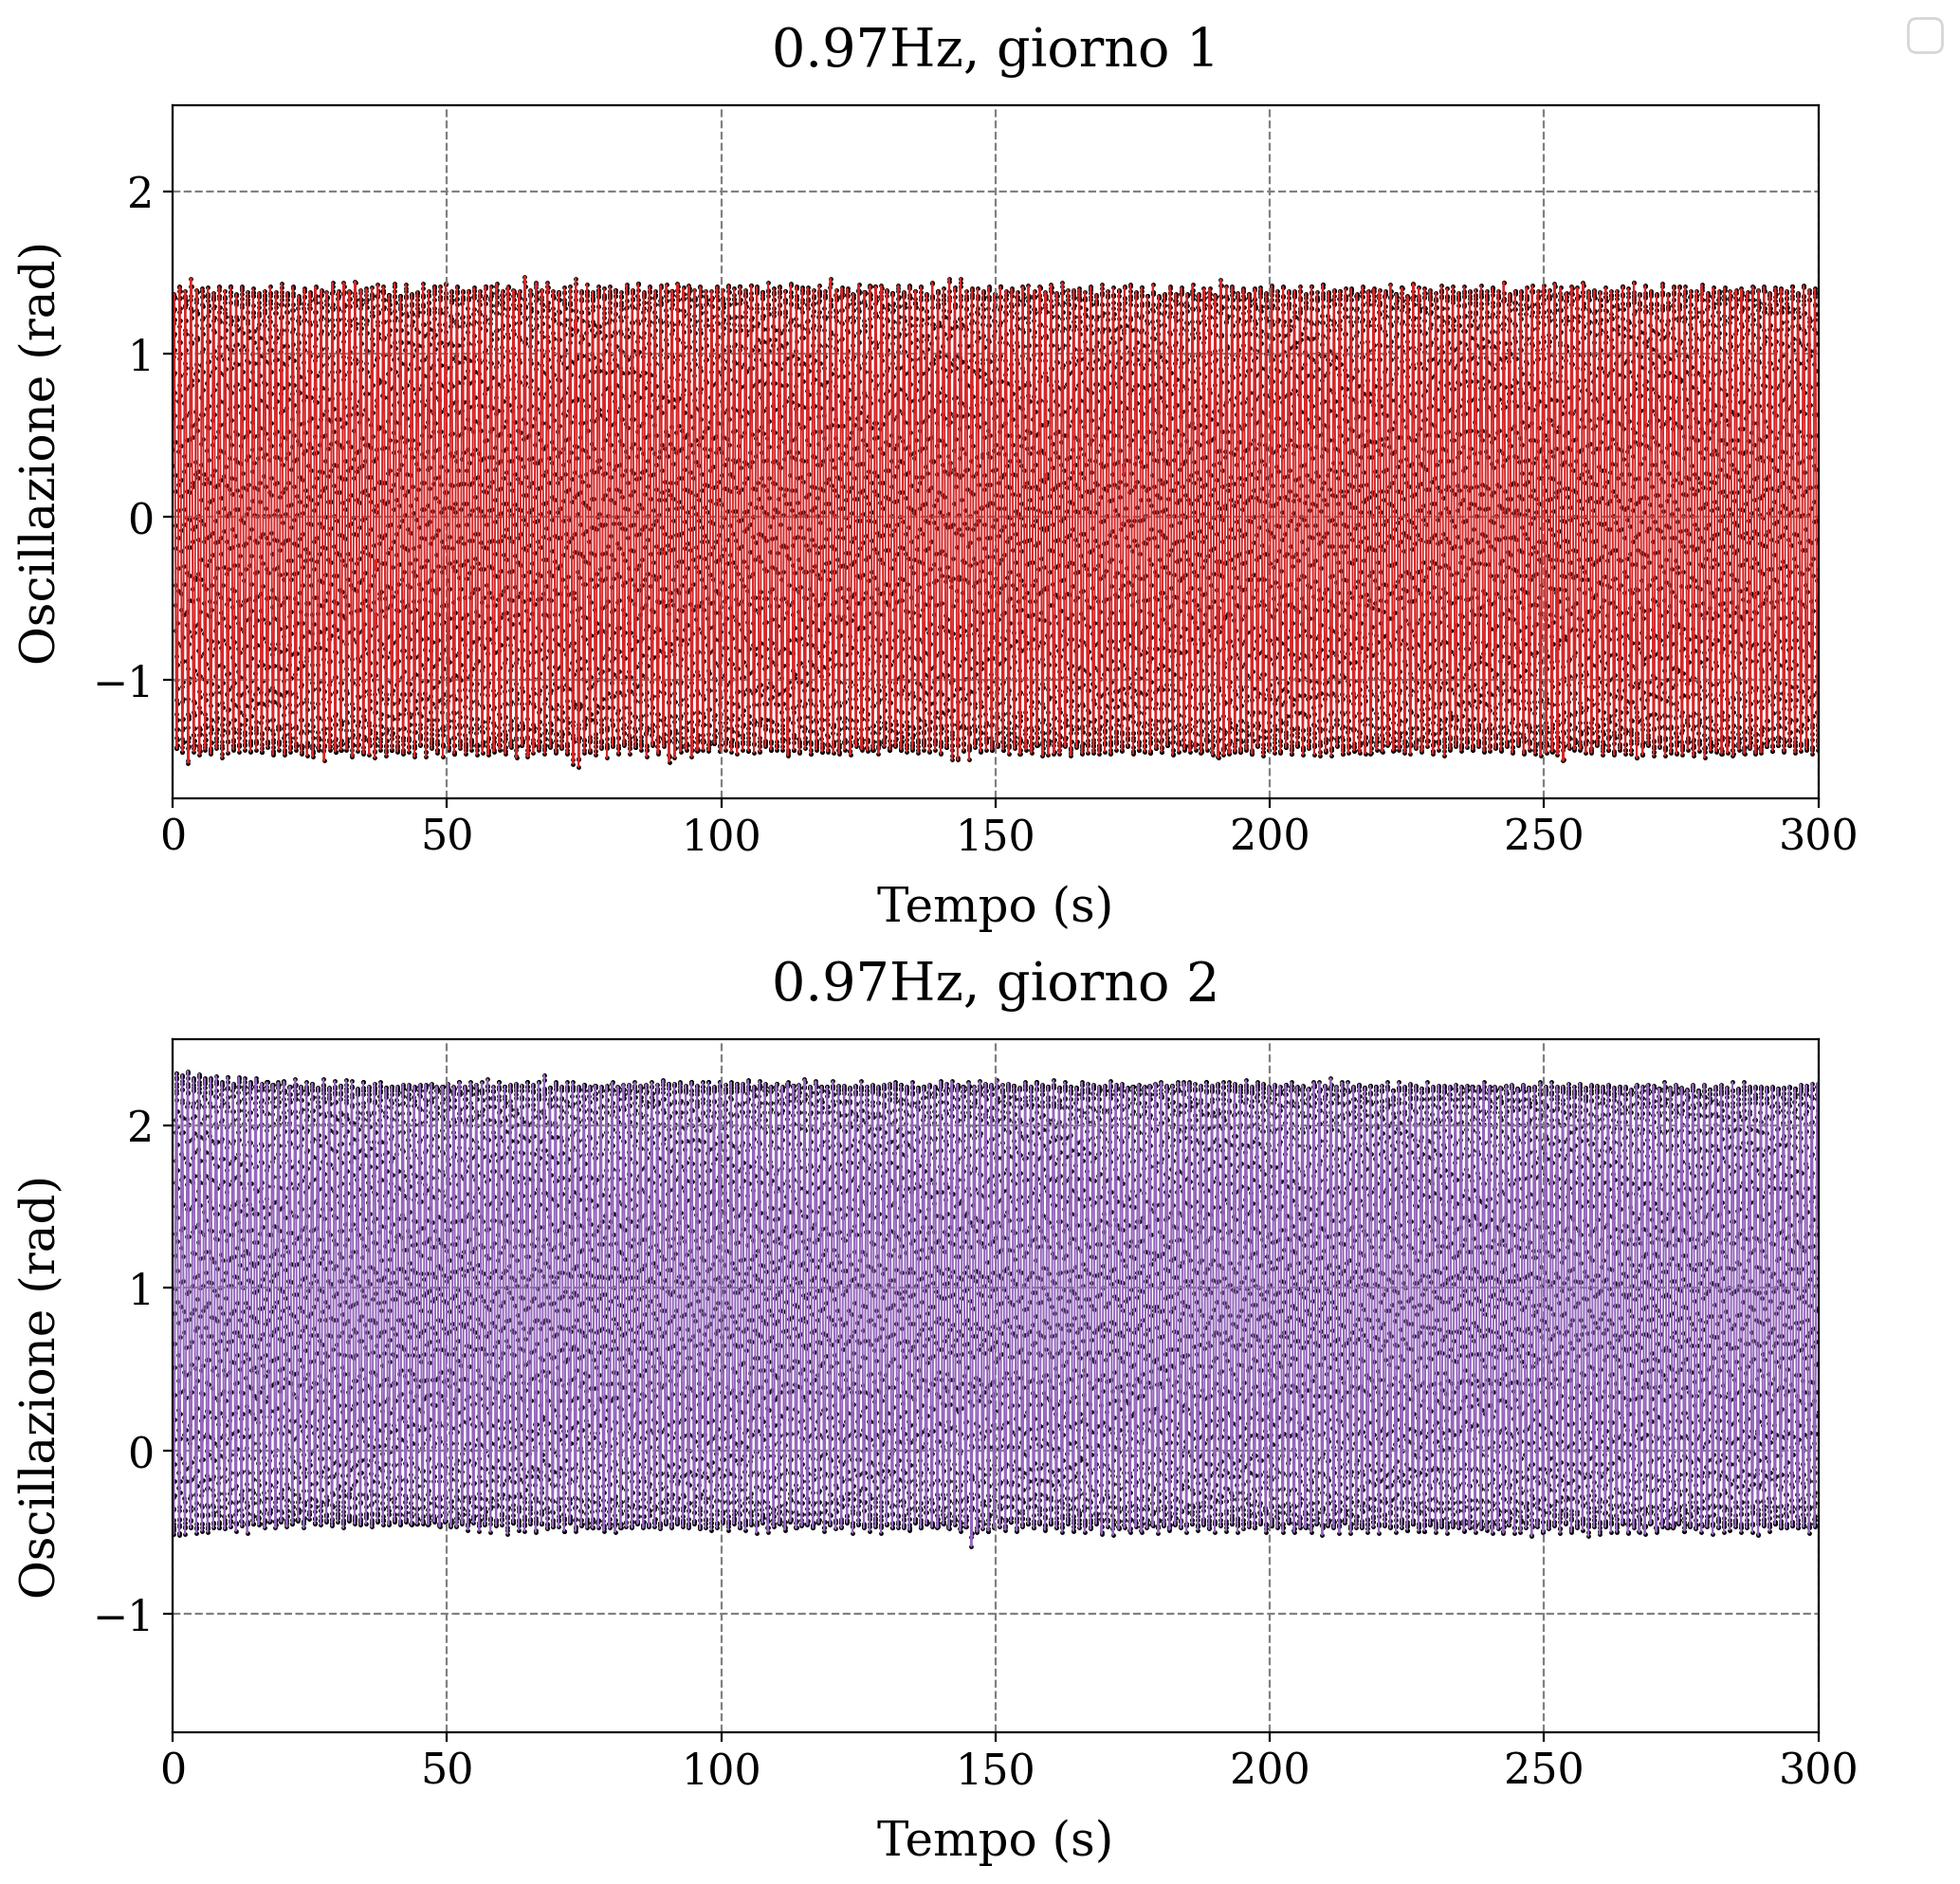

In [50]:
fig,axes = plt.subplots(2, 1, figsize=(10, 2*5), sharey=True)

for i, dati in enumerate([dati1, dati2]):
    ax = axes[i]

    titolo = "0.97Hz"
    colore = next(color_cycle)

    x = dati[titolo]["tempo"]
    y = dati[titolo]["pendolo"] * (2*np.pi)

    ax.plot(x, y, color=colore, linewidth=0.7)
    ax.scatter(x, y, color="black", s=0.5)

    gf.parametri_grafico(ax, titolo + f", giorno {i+1}", "Tempo (s)", "Oscillazione (rad)")
    ax.set_xlim(0,300)
gf.salva_grafico(fig, f"./Images/ConfrontoForzanti.pdf")